In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("data/raw/playerdata.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    571 non-null    object 
 1   Jersey Number           563 non-null    float64
 2   Club                    571 non-null    object 
 3   Position                571 non-null    object 
 4   Nationality             570 non-null    object 
 5   Age                     570 non-null    float64
 6   Appearances             571 non-null    int64  
 7   Wins                    571 non-null    int64  
 8   Losses                  571 non-null    int64  
 9   Goals                   571 non-null    int64  
 10  Goals per match         309 non-null    float64
 11  Headed goals            502 non-null    float64
 12  Goals with right foot   502 non-null    float64
 13  Goals with left foot    502 non-null    float64
 14  Penalties scored        309 non-null    fl

In [4]:
df.columns

Index(['Name', 'Jersey Number', 'Club', 'Position', 'Nationality', 'Age',
       'Appearances', 'Wins', 'Losses', 'Goals', 'Goals per match',
       'Headed goals', 'Goals with right foot', 'Goals with left foot',
       'Penalties scored', 'Freekicks scored', 'Shots', 'Shots on target',
       'Shooting accuracy %', 'Hit woodwork', 'Big chances missed',
       'Clean sheets', 'Goals conceded', 'Tackles', 'Tackle success %',
       'Last man tackles', 'Blocked shots', 'Interceptions', 'Clearances',
       'Headed Clearance', 'Clearances off line', 'Recoveries', 'Duels won',
       'Duels lost', 'Successful 50/50s', 'Aerial battles won',
       'Aerial battles lost', 'Own goals', 'Errors leading to goal', 'Assists',
       'Passes', 'Passes per match', 'Big chances created', 'Crosses',
       'Cross accuracy %', 'Through balls', 'Accurate long balls', 'Saves',
       'Penalties saved', 'Punches', 'High Claims', 'Catches',
       'Sweeper clearances', 'Throw outs', 'Goal Kicks', 'Yellow 

Missing Values Analysis

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

Throw outs                502
Sweeper clearances        502
Catches                   502
High Claims               502
Punches                   502
Penalties saved           502
Saves                     502
Goal Kicks                502
Last man tackles          378
Clearances off line       378
Goals conceded            309
Own goals                 309
Clean sheets              309
Freekicks scored          262
Shots                     262
Penalties scored          262
Goals per match           262
Shots on target           262
Shooting accuracy %       262
Big chances missed        262
Aerial battles won        181
Recoveries                181
Successful 50/50s         181
Duels lost                181
Duels won                 181
Aerial battles lost       181
Tackle success %          181
Cross accuracy %          181
Through balls             181
Accurate long balls       112
Errors leading to goal    112
Interceptions              69
Headed Clearance           69
Clearances

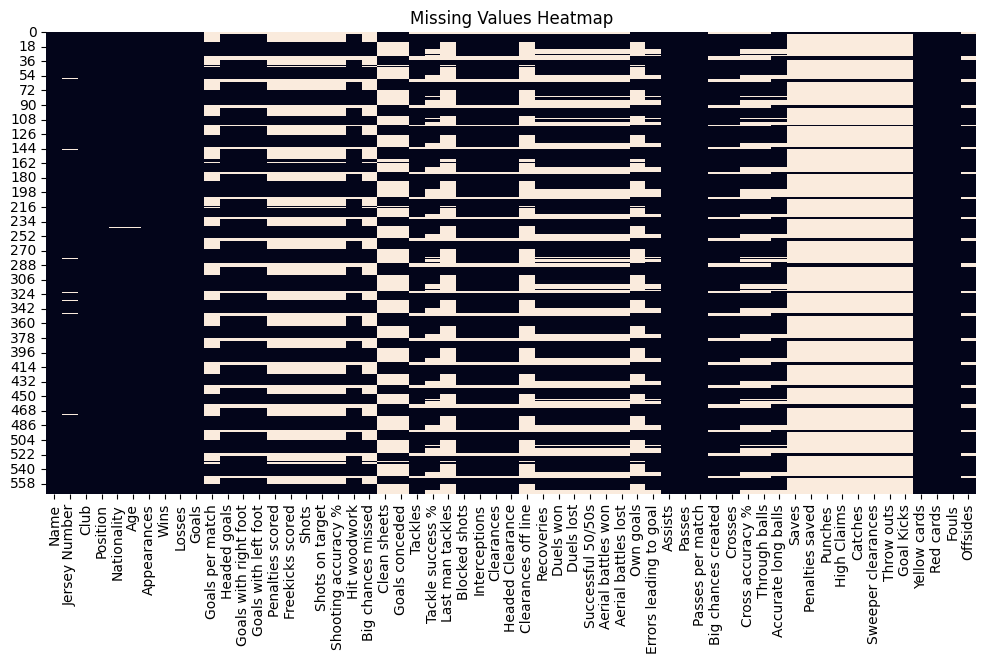

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

Data cleaning

In [10]:
df["Shooting accuracy %"] = df["Shooting accuracy %"].str.replace("%","").astype(float)
df["Tackle success %"] = df["Tackle success %"].str.replace("%","").astype(float)
df["Cross accuracy %"] = df["Cross accuracy %"].str.replace("%","").astype(float)

Player Position Distribution

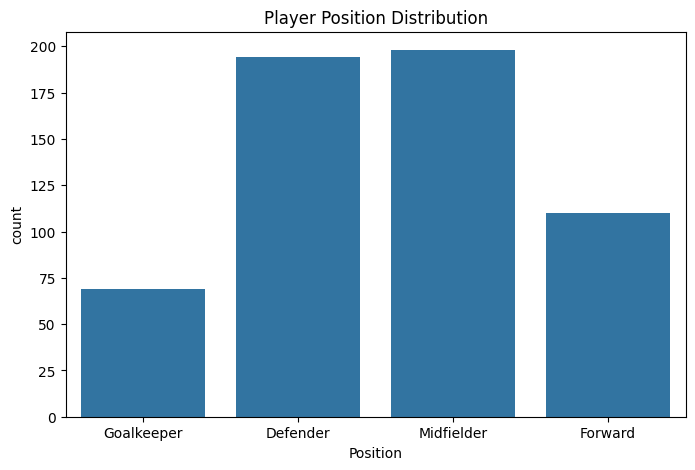

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="Position", data=df)
plt.title("Player Position Distribution")
plt.show()

Age Distribution

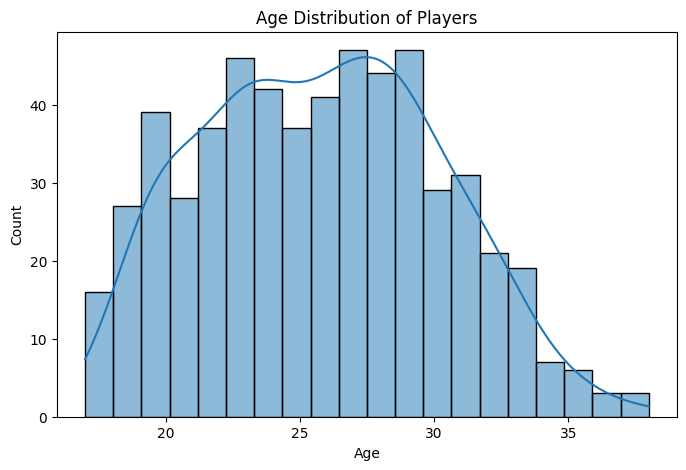

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Players")
plt.show()

Top Goal Scorers

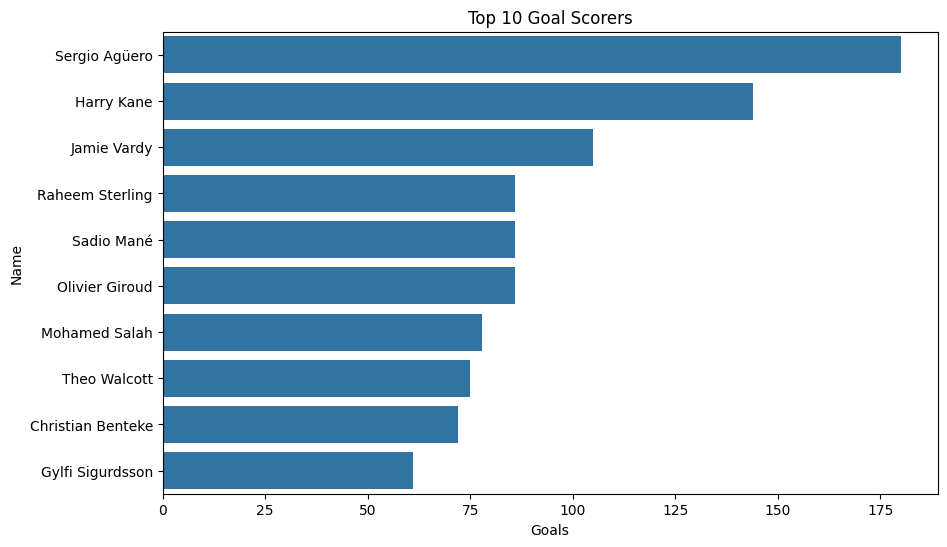

In [13]:
top_scorers = df.sort_values("Goals", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Goals", y="Name", data=top_scorers)
plt.title("Top 10 Goal Scorers")
plt.show()

Top Assist Providers

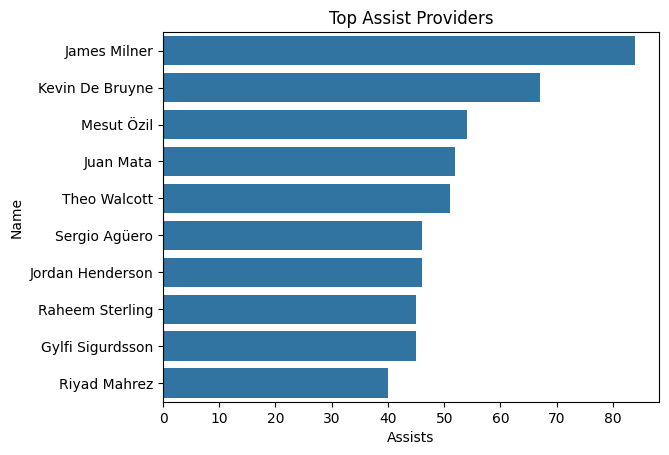

In [14]:
top_assists = df.sort_values("Assists", ascending=False).head(10)

sns.barplot(x="Assists", y="Name", data=top_assists)
plt.title("Top Assist Providers")
plt.show()

Goals vs Appearances

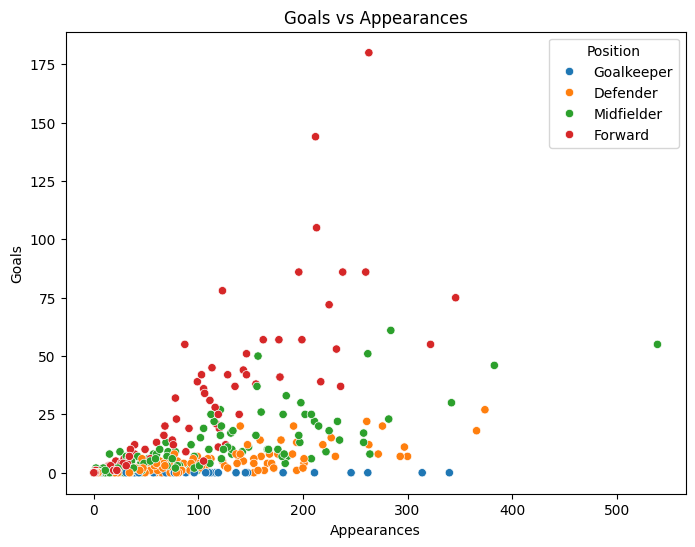

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Appearances", y="Goals", hue="Position", data=df)
plt.title("Goals vs Appearances")
plt.show()

Correlation Analysis

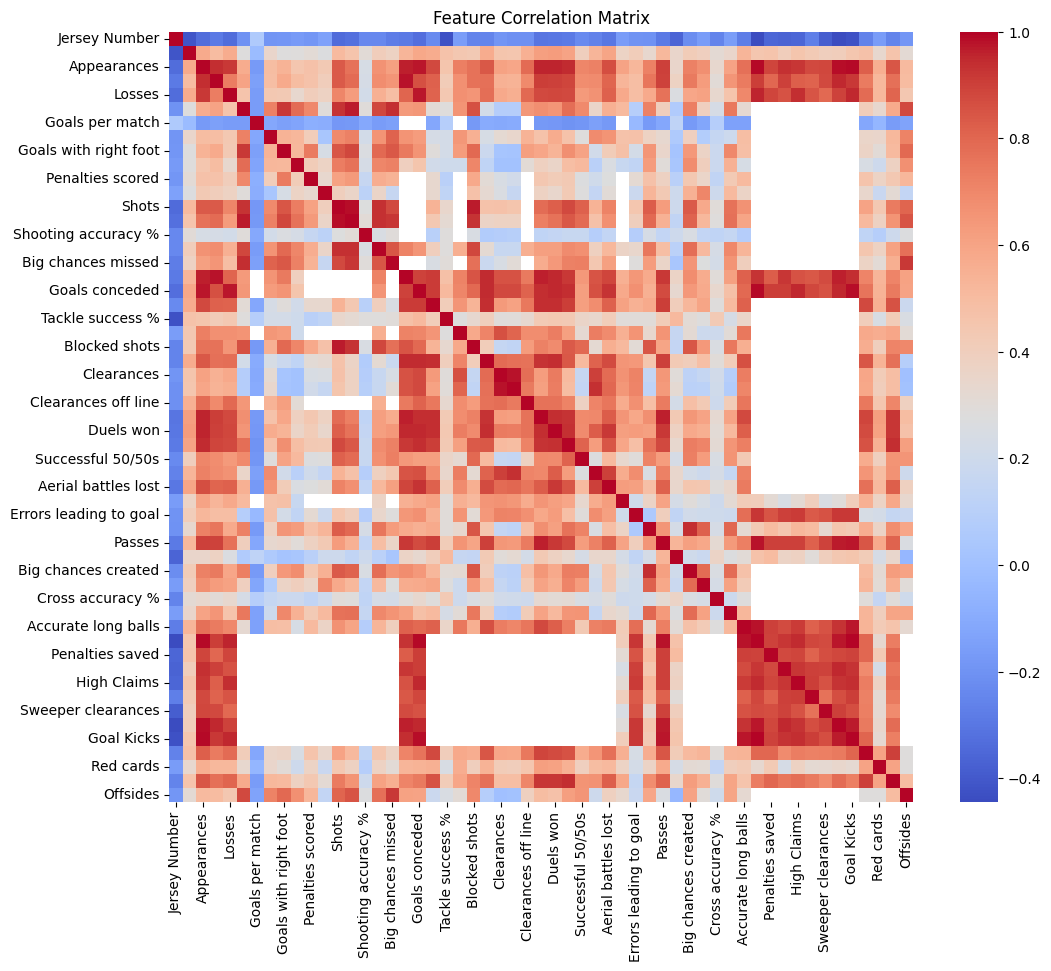

In [16]:
plt.figure(figsize=(12,10))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()